# Langkah 1: Load Data & Model Baseline


In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
elif not (project_root / "data").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from preprocessing import create_time_features, get_feature_target
from evaluate_model import (
    calculate_regression_metrics,
    create_ct_checklist,
    create_prediction_result_dataframe,
    evaluate_by_group,
    save_report,
)
from data_validation import run_all_validations

cleaned_data_path = project_root / "data" / "processed" / "cleaned_cab_rides.csv"
model_path = project_root / "models" / "baseline_price_model.joblib"
model_report_path = project_root / "reports" / "model_evaluation_report.md"
quality_checklist_path = project_root / "reports" / "quality_checklist.md"

print("Project root:", project_root)
print("Cleaned data path:", cleaned_data_path)
print("Model path:", model_path)





Project root: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online
Cleaned data path: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\data\processed\cleaned_cab_rides.csv
Model path: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\models\baseline_price_model.joblib


In [2]:
cleaned_cab_rides = pd.read_csv(cleaned_data_path)
baseline_model = joblib.load(model_path)

print("Cleaned dataset shape:", cleaned_cab_rides.shape)
print("Loaded model type:", type(baseline_model).__name__)
display(cleaned_cab_rides.head())





Cleaned dataset shape: (637976, 10)
Loaded model type: Pipeline


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
invalid_datetime_rows = pd.to_datetime(
    cleaned_cab_rides["time_stamp"],
    unit="ms",
    errors="coerce",
).isna().sum()

model_data = create_time_features(cleaned_cab_rides)
X, y, feature_columns, numeric_features, categorical_features = get_feature_target(
    model_data,
    include_surge=False,
)
target_column = "price"

print("Invalid datetime rows dropped by time feature step:", invalid_datetime_rows)
print("Selected feature columns:")
for feature in feature_columns:
    print("-", feature)
print("Target column:", target_column)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)





Invalid datetime rows dropped by time feature step: 0
Selected feature columns:
- distance
- cab_type
- source
- destination
- name
- hour
- day
- month
- day_of_week
Target column: price
Numerical features: ['distance', 'hour', 'day', 'month', 'day_of_week']
Categorical features: ['cab_type', 'source', 'destination', 'name']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

y_pred = baseline_model.predict(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Prediction shape:", y_pred.shape)
print("Model runs successfully:", len(y_pred) == len(y_test))





Train shape: (510380, 9)
Test shape: (127596, 9)
Prediction shape: (127596,)
Model runs successfully: True


# Langkah 2: Evaluasi Metrik Keseluruhan


In [5]:
metrics = calculate_regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "Mean Actual Price", "Median Actual Price"],
    "Value": [
        metrics["MAE"],
        metrics["RMSE"],
        metrics["R2 Score"],
        metrics["Mean Actual Price"],
        metrics["Median Actual Price"],
    ],
})

display(metrics_df)

mae_vs_mean_pct = metrics["MAE"] / metrics["Mean Actual Price"] * 100
mae_vs_median_pct = metrics["MAE"] / metrics["Median Actual Price"] * 100

print(f"MAE compared with mean actual price: {mae_vs_mean_pct:.2f}%")
print(f"MAE compared with median actual price: {mae_vs_median_pct:.2f}%")





,Metric,Value
0,MAE,1.425413
1,RMSE,2.618088
2,R2 Score,0.921377
3,Mean Actual Price,16.542276
4,Median Actual Price,13.500000


MAE compared with mean actual price: 8.62%
MAE compared with median actual price: 10.56%


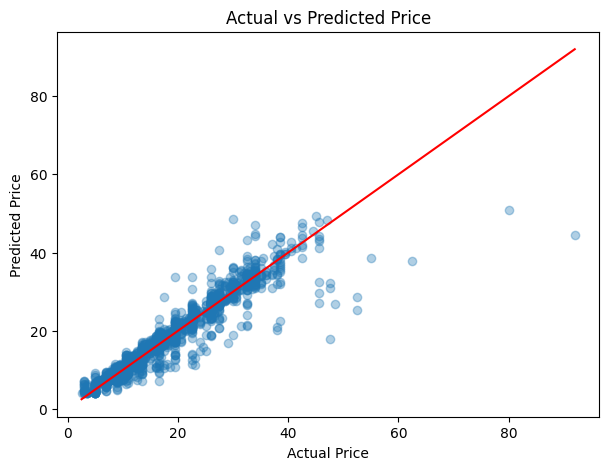

In [6]:
plot_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
actual_sample = y_test.loc[plot_sample.index]
predicted_sample = baseline_model.predict(plot_sample)

plt.figure(figsize=(7, 5))
plt.scatter(actual_sample, predicted_sample, alpha=0.35)
plt.plot(
    [actual_sample.min(), actual_sample.max()],
    [actual_sample.min(), actual_sample.max()],
    color="red",
)
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()





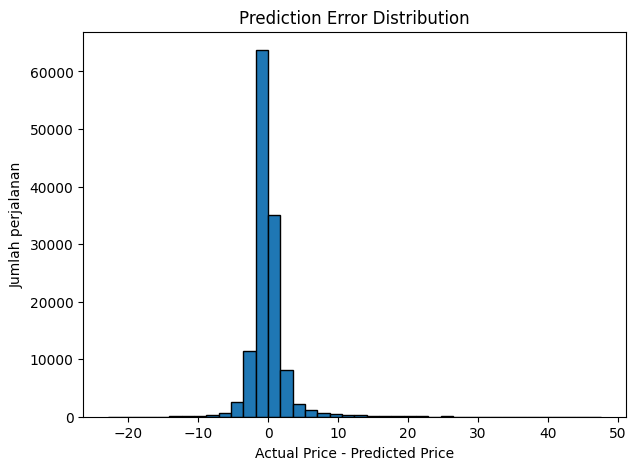

In [7]:
prediction_errors = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.hist(prediction_errors, bins=40, edgecolor="black")
plt.title("Prediction Error Distribution")
plt.xlabel("Actual Price - Predicted Price")
plt.ylabel("Jumlah perjalanan")
plt.show()





# Langkah 3: Error per Grup


In [8]:
result_df = create_prediction_result_dataframe(X_test, y_test, y_pred)

result_df["distance_group"] = pd.qcut(
    result_df["distance"],
    q=3,
    labels=["short trip", "medium trip", "long trip"],
)

selected_result_columns = [
    "actual_price",
    "predicted_price",
    "absolute_error",
    "distance",
    "distance_group",
    "cab_type",
    "source",
    "destination",
    "name",
]

display(result_df[selected_result_columns].head())





,actual_price,predicted_price,absolute_error,distance,distance_group,cab_type,source,destination,name
484718,7.0,8.828376,1.828376,4.51,long trip,Lyft,Financial District,Fenway,Shared
466257,10.5,10.620882,0.120882,2.80,long trip,Uber,West End,Boston University,WAV
128490,7.0,7.579107,0.579107,1.09,short trip,Lyft,South Station,Theatre District,Lyft
216568,15.5,15.728474,0.228474,0.92,short trip,Uber,Financial District,Haymarket Square,Black
129302,16.5,16.690904,0.190904,1.12,short trip,Lyft,North End,North Station,Lux Black


In [9]:
distance_error = evaluate_by_group(result_df, "distance_group")
cab_type_error = evaluate_by_group(result_df, "cab_type")
name_error = evaluate_by_group(result_df, "name")
source_error = evaluate_by_group(result_df, "source")
destination_error = evaluate_by_group(result_df, "destination")

print("Error by distance group:")
display(distance_error)

print("Error by cab type:")
display(cab_type_error)

print("Error by ride service name:")
display(name_error)





Error by distance group:


,distance_group,row_count,MAE,RMSE
2,long trip,42101,1.828477,3.342571
1,medium trip,42552,1.484566,2.510905
0,short trip,42943,0.971639,1.779153


Error by cab type:


,cab_type,row_count,MAE,RMSE
0,Lyft,61339,1.672348,3.193459
1,Uber,66257,1.196807,1.938758


Error by ride service name:


,name,row_count,MAE,RMSE
4,Lux Black XL,10183,2.913570,5.303745
3,Lux Black,10378,2.022643,3.648355
2,Lux,10181,1.624340,2.888011
10,UberXL,11064,1.576041,2.688481
6,Lyft XL,10204,1.508761,2.596457
1,Black SUV,10966,1.412649,2.196520
0,Black,11019,1.248186,1.863059
7,Shared,10299,1.091411,1.555270
9,UberX,11107,0.992270,1.590553
11,WAV,11146,0.984789,1.558071


In [10]:
print("Top source groups by MAE:")
display(source_error.head(10))

print("Top destination groups by MAE:")
display(destination_error.head(10))





Top source groups by MAE:


,source,row_count,MAE,RMSE
3,Fenway,10727,1.868104,3.347889
8,Northeastern University,10665,1.838689,3.192946
0,Back Bay,10683,1.777021,3.204087
2,Boston University,10658,1.724704,3.239210
10,Theatre District,10417,1.654135,3.064359
4,Financial District,10818,1.475980,2.938993
1,Beacon Hill,10571,1.430087,2.478363
9,South Station,10467,1.327857,2.294188
7,North Station,10464,1.083191,1.828975
11,West End,10657,1.069658,1.771055


Top destination groups by MAE:


,destination,row_count,MAE,RMSE
2,Boston University,10551,1.638209,3.077739
8,Northeastern University,10723,1.585850,2.725764
4,Financial District,10798,1.551509,3.155174
3,Fenway,10696,1.535452,2.703981
0,Back Bay,10930,1.438725,2.406136
7,North Station,10476,1.428070,2.730897
10,Theatre District,10544,1.424014,2.476603
1,Beacon Hill,10696,1.400279,2.363386
11,West End,10542,1.367146,2.520606
6,North End,10541,1.281784,2.456768


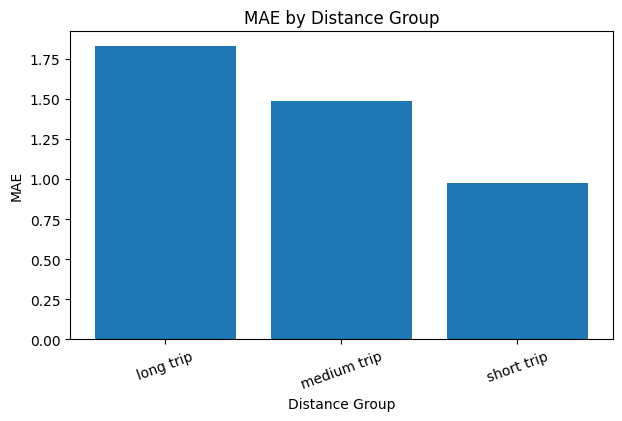

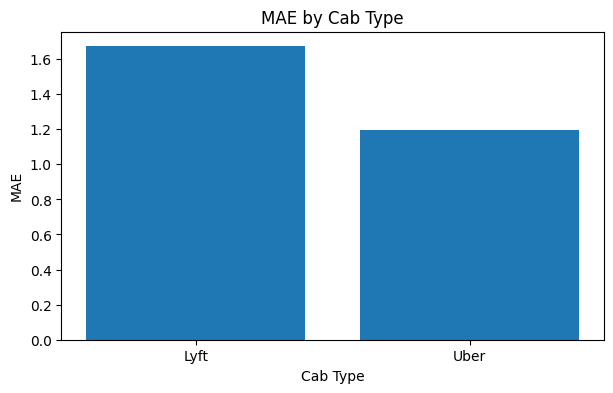

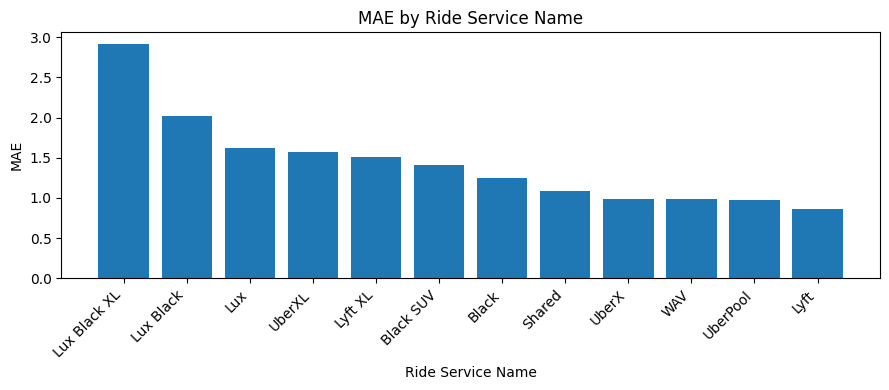

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(distance_error["distance_group"].astype(str), distance_error["MAE"])
plt.title("MAE by Distance Group")
plt.xlabel("Distance Group")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(cab_type_error["cab_type"].astype(str), cab_type_error["MAE"])
plt.title("MAE by Cab Type")
plt.xlabel("Cab Type")
plt.ylabel("MAE")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(name_error["name"].astype(str), name_error["MAE"])
plt.title("MAE by Ride Service Name")
plt.xlabel("Ride Service Name")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()





In [12]:
group_tables = {
    "distance_group": distance_error,
    "cab_type": cab_type_error,
    "name": name_error,
    "source": source_error,
    "destination": destination_error,
}

highest_error_candidates = []
for group_name, table in group_tables.items():
    top_row = table.sort_values("MAE", ascending=False).iloc[0]
    group_value = top_row[group_name]
    highest_error_candidates.append({
        "Group Type": group_name,
        "Group Value": str(group_value),
        "MAE": float(top_row["MAE"]),
        "RMSE": float(top_row["RMSE"]),
        "Row Count": int(top_row["row_count"]),
    })

highest_error_summary = pd.DataFrame(highest_error_candidates).sort_values("MAE", ascending=False)
highest_error_group = highest_error_summary.iloc[0]

display(highest_error_summary)
print(
    "Highest error group:",
    f"{highest_error_group['Group Type']} = {highest_error_group['Group Value']}",
    f"with MAE {highest_error_group['MAE']:.4f}.",
)
print("Short interpretation: this group should be reviewed in the next feature engineering step because its average error is higher than other groups.")





,Group Type,Group Value,MAE,RMSE,Row Count
2,name,Lux Black XL,2.913570,5.303745,10183
3,source,Fenway,1.868104,3.347889,10727
0,distance_group,long trip,1.828477,3.342571,42101
1,cab_type,Lyft,1.672348,3.193459,61339
4,destination,Boston University,1.638209,3.077739,10551


Highest error group: name = Lux Black XL with MAE 2.9136.
Short interpretation: this group should be reviewed in the next feature engineering step because its average error is higher than other groups.


# Langkah 4: Validasi CI


In [13]:
ci_checklist = run_all_validations(cleaned_cab_rides)
display(ci_checklist)

ci_status_summary = ci_checklist["Status"].value_counts().rename_axis("Status").reset_index(name="Count")
display(ci_status_summary)





,Check Name,Rule,Failed Rows,Status,Recommendation
0,Kolom wajib,"Wajib: price, distance, cab_type, source, dest...",0,PASS,Kolom lengkap.
1,Target price,Target 'price' tidak boleh null,0,PASS,Target valid.
2,distance > 0,distance harus > 0,0,PASS,Distance valid.
3,price > 0,price harus > 0,0,PASS,Price valid.
4,time_stamp valid datetime,time_stamp harus valid konversi pd.to_datetime,0,PASS,Timestamp valid.
5,Tidak ada baris duplikat,Data tidak boleh ada duplikat persis,0,PASS,Tidak ada duplikat.
6,source tidak null,Kolom 'source' tidak boleh null,0,PASS,source valid.
7,destination tidak null,Kolom 'destination' tidak boleh null,0,PASS,destination valid.
8,cab_type tidak null,Kolom 'cab_type' tidak boleh null,0,PASS,cab_type valid.
9,name tidak null,Kolom 'name' tidak boleh null,0,PASS,name valid.


,Status,Count
0,PASS,10


# Langkah 5: Validasi CT


In [14]:
ct_group_tables = {
    "distance_group": distance_error,
    "cab_type": cab_type_error,
    "name": name_error,
}

ct_checklist = create_ct_checklist(metrics, ct_group_tables)
display(ct_checklist)

ct_status_summary = ct_checklist["Status"].value_counts().rename_axis("Status").reset_index(name="Count")
display(ct_status_summary)





,Check Name,Metric / Rule,Current Value,Threshold,Status,Recommendation
0,Cek threshold MAE,MAE <= 2.00,1.4254,2.00,PASS,Monitor MAE.
1,Cek threshold RMSE,RMSE <= 3.50,2.6181,3.50,PASS,Cek error besar jika RMSE naik.
2,Cek threshold R2 score,R2 Score >= 0.85,0.9214,0.85,PASS,Cek fitur/model jika R2 turun.
3,Error per grup jarak,MAE grup tidak boleh wajar,1.8285,<= 2.1381,PASS,Cek kualitas fitur.
4,Error per cab_type,MAE grup tidak boleh wajar,1.6723,<= 2.1381,PASS,Cek kualitas fitur.
5,Error per layanan,MAE grup tidak boleh wajar,2.9136,<= 2.1381,WARNING,Cek kualitas fitur.
6,Review distribusi error,Review distribusi residual,Direview di notebook,Tidak ada pola aneh,PASS,Lanjut cek plot.
7,Robustness jarak pendek/jauh,Review per jarak,Direview per grup,MAE tidak wajar,PASS,Lanjut cek per grup.


,Status,Count
0,PASS,7
1,WARNING,1


In [15]:
print("Ringkasan Akhir Langkah 3")
print("Dataset used: data/processed/cleaned_cab_rides.csv")
print("Model evaluated: models/baseline_price_model.joblib")
print(f"MAE: {metrics['MAE']:.4f}")
print(f"RMSE: {metrics['RMSE']:.4f}")
print(f"R2 Score: {metrics['R2 Score']:.4f}")
print(
    "Highest error group:",
    f"{highest_error_group['Group Type']} = {highest_error_group['Group Value']}",
    f"with MAE {highest_error_group['MAE']:.4f}",
)
print("CI checklist status summary:")
print(ci_status_summary.to_string(index=False))
print("CT checklist status summary:")
print(ct_status_summary.to_string(index=False))
print("Next step recommendation: improve features, review high-error groups, and plan weather data merging carefully before later deployment work.")





Ringkasan Akhir Langkah 3
Dataset used: data/processed/cleaned_cab_rides.csv
Model evaluated: models/baseline_price_model.joblib
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Highest error group: name = Lux Black XL with MAE 2.9136
CI checklist status summary:
Status  Count
  PASS     10
CT checklist status summary:
 Status  Count
   PASS      7
WARNING      1
Next step recommendation: improve features, review high-error groups, and plan weather data merging carefully before later deployment work.
